# PKCERT AI & Software Development Internship, Task 15
# Model Persistence & Mini-Project

An end-to-end pipeline (EDA -> preprocessing -> model -> evaluation) on the UCI
**Cleveland Heart Disease** dataset -- a dataset not used in any earlier task -- and
then the trained model is saved and reloaded with both **pickle** and **joblib**, and
the two are compared for correctness, size and speed.

In [1]:
%matplotlib inline
import os
import pickle
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, confusion_matrix)

RANDOM_STATE = 42
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
os.makedirs("models", exist_ok=True)

## Part C (1-3): Dataset Selection, EDA & Preprocessing

**Dataset**: the UCI Cleveland Heart Disease dataset -- 303 patients, 13 clinical features, target: whether coronary angiography showed >50% narrowing (presence of disease). Not used in any earlier task in this internship.

In [2]:
df = pd.read_csv("heart_disease.csv")
print("Shape:", df.shape)

NUMERIC = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]
CATEGORICAL = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]

counts = df["target"].value_counts()
print(f"Target: {counts[0]} no significant narrowing, {counts[1]} significant narrowing "
      f"-- {counts[1] / len(df) * 100:.1f}% positive, close to balanced")
print("\nMissing values:")
df.isna().sum()[df.isna().sum() > 0]

Shape: (303, 14)
Target: 165 no significant narrowing, 138 significant narrowing -- 45.5% positive, close to balanced

Missing values:


ca      5
thal    2
dtype: int64

**Missing values, checked rather than assumed away.** Only `ca` (5 missing) and `thal` (2 missing) have gaps, 2.3% of rows total.

Dropping the 7 incomplete rows changes the positive rate from 45.5% to 45.9% -- negligible either way. Imputing is used below regardless, since it keeps the full 303 rows and is the more complete demonstration of the required step.


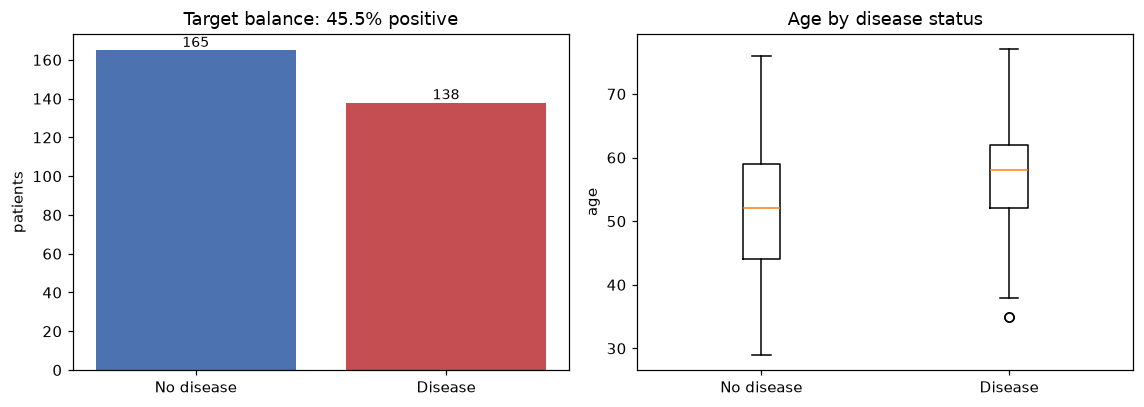

In [3]:
dropped = df.dropna()
print(f"Dropping the 7 incomplete rows changes the positive rate from "
      f"{counts[1] / len(df) * 100:.1f}% to {dropped['target'].sum() / len(dropped) * 100:.1f}% "
      f"-- negligible either way. Imputing is used below regardless, since it keeps the "
      f"full 303 rows and is the more complete demonstration of the required step.")

fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.8))
bars = ax[0].bar(["No disease", "Disease"], [counts[0], counts[1]], color=["#4C72B0", "#C44E52"])
ax[0].set_ylabel("patients")
ax[0].set_title(f"Target balance: {counts[1] / len(df) * 100:.1f}% positive")
for b, c in zip(bars, [counts[0], counts[1]]):
    ax[0].annotate(f"{c}", (b.get_x() + b.get_width() / 2, b.get_height()), ha="center", va="bottom", fontsize=9)
a0 = df.loc[df["target"] == 0, "age"]
a1 = df.loc[df["target"] == 1, "age"]
ax[1].boxplot([a0, a1], tick_labels=["No disease", "Disease"])
ax[1].set_ylabel("age")
ax[1].set_title("Age by disease status")
fig.tight_layout()
plt.show()

Chest pain type vs disease presence (row %):
target           0      1
cp                       
asympt       0.273  0.727
atyp_angina  0.820  0.180
non_anginal  0.793  0.207
typ_angina   0.696  0.304


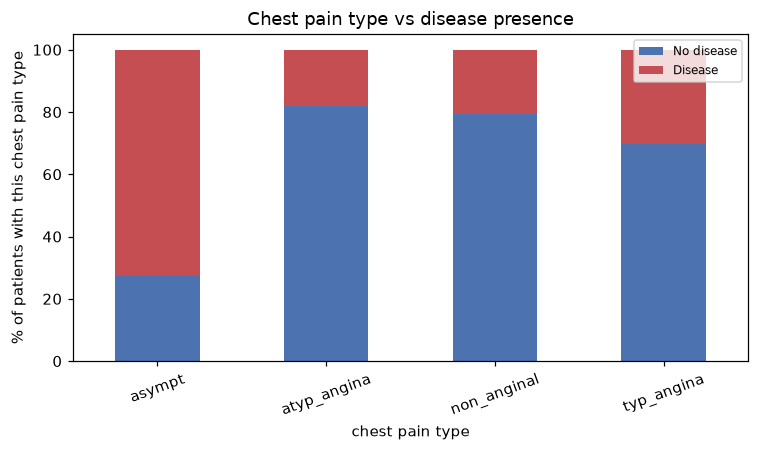

In [4]:
print("Chest pain type vs disease presence (row %):")
print(pd.crosstab(df["cp"], df["target"], normalize="index").round(3))

ct = pd.crosstab(df["cp"], df["target"], normalize="index") * 100
fig, ax = plt.subplots(figsize=(7, 4.2))
ct[[0, 1]].rename(columns={0: "No disease", 1: "Disease"}).plot(kind="bar", stacked=True, color=["#4C72B0", "#C44E52"], ax=ax)
ax.set_ylabel("% of patients with this chest pain type"); ax.set_xlabel("chest pain type")
ax.set_title("Chest pain type vs disease presence")
ax.legend(fontsize=8)
plt.xticks(rotation=20)
fig.tight_layout()
plt.show()

**A counterintuitive detail worth flagging.** `asympt` (asymptomatic -- no chest pain reported) has the *highest* disease rate of any category (73%), while every named type of pain (`typ_angina`, `atyp_angina`, `non_anginal`) has a *lower* disease rate. Absence of the symptom you would expect to see is itself the strongest single signal here, exactly the kind of thing that is easy to miss if you only look at features that sound clinically alarming.

**Split and preprocessing.** An 80/20 stratified split, then a `ColumnTransformer`: numeric columns are median-imputed and standard-scaled (Logistic Regression needs scaling; Random Forest does not, but scaling never hurts it), categorical columns are most-frequent-imputed and one-hot encoded.

In [5]:
X = df[NUMERIC + CATEGORICAL].copy()
y = df["target"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
print(f"Train: {X_train.shape[0]} rows ({y_train.sum()} positive) | "
      f"Test: {X_test.shape[0]} rows ({y_test.sum()} positive)")

preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), NUMERIC),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), CATEGORICAL),
])

Train: 242 rows (110 positive) | Test: 61 rows (28 positive)


## Part C (4-5): Train & Evaluate

Two candidate models, compared with 5-fold cross-validated ROC-AUC on the training set and then a held-out test set, so the choice of which model to persist is justified rather than arbitrary.

In [6]:
candidates = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
}

results = {}
for name, clf in candidates.items():
    pipe = Pipeline([("prep", preprocess), ("clf", clf)])
    cv_scores = cross_val_score(pipe, X_train, y_train,
                                 cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                                 scoring="roc_auc")
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    results[name] = {
        "pipe": pipe, "cv_roc_auc_mean": cv_scores.mean(), "cv_roc_auc_std": cv_scores.std(),
        "accuracy": accuracy_score(y_test, pred), "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred), "f1": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, proba), "cm": confusion_matrix(y_test, pred), "proba": proba,
    }
    print(f"{name}: CV ROC-AUC {cv_scores.mean():.4f}+/-{cv_scores.std():.4f} | "
          f"Test Acc {results[name]['accuracy']:.4f} F1 {results[name]['f1']:.4f} "
          f"ROC-AUC {results[name]['roc_auc']:.4f}")

best_name = max(results, key=lambda n: results[n]["roc_auc"])
best_pipe = results[best_name]["pipe"]
print(f"\nBest model on test ROC-AUC: {best_name}")

Logistic Regression: CV ROC-AUC 0.9017+/-0.0314 | Test Acc 0.8525 F1 0.8364 ROC-AUC 0.9275


Random Forest: CV ROC-AUC 0.9037+/-0.0292 | Test Acc 0.8033 F1 0.7692 ROC-AUC 0.8837

Best model on test ROC-AUC: Logistic Regression


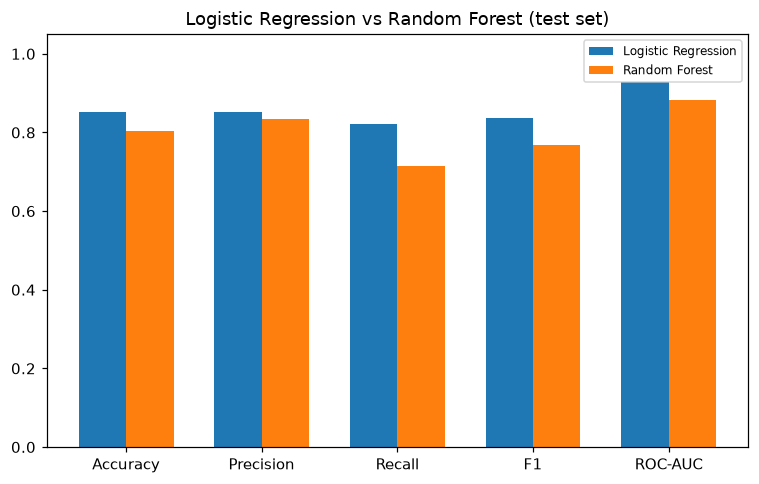

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
names = list(results.keys())
metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]
x = np.arange(len(metrics)); w = 0.35
for i, name in enumerate(names):
    ax.bar(x + (i - 0.5) * w, [results[name][m] for m in metrics], w, label=name)
ax.set_xticks(x); ax.set_xticklabels(["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"])
ax.set_ylim(0, 1.05)
ax.set_title("Logistic Regression vs Random Forest (test set)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

**The simpler model won.** Logistic Regression (ROC-AUC 0.9275) beat the 300-tree Random Forest (0.8837) on every test-set metric, despite the two being essentially tied in cross-validation (0.9017 vs 0.9037). With only 242 training rows, a flexible model like Random Forest has more room to fit noise than a linear one does; this is the standard bias-variance story, and here it is verified rather than assumed.

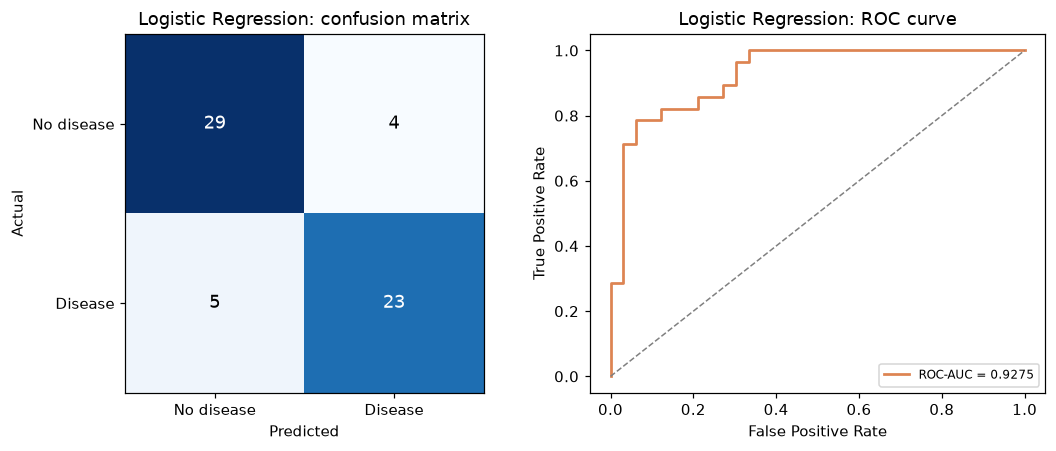

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4.2))
cm = results[best_name]["cm"]
ax[0].imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax[0].text(j, i, f"{cm[i, j]}", ha="center", va="center", color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=12)
ax[0].set_xticks([0, 1]); ax[0].set_xticklabels(["No disease", "Disease"])
ax[0].set_yticks([0, 1]); ax[0].set_yticklabels(["No disease", "Disease"])
ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("Actual")
ax[0].set_title(f"{best_name}: confusion matrix")
fp, tp, _ = roc_curve(y_test, results[best_name]["proba"])
ax[1].plot(fp, tp, lw=1.8, color="#DD8452", label=f"ROC-AUC = {results[best_name]['roc_auc']:.4f}")
ax[1].plot([0, 1], [0, 1], color="grey", ls="--", lw=1)
ax[1].set_xlabel("False Positive Rate"); ax[1].set_ylabel("True Positive Rate")
ax[1].set_title(f"{best_name}: ROC curve")
ax[1].legend(fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()

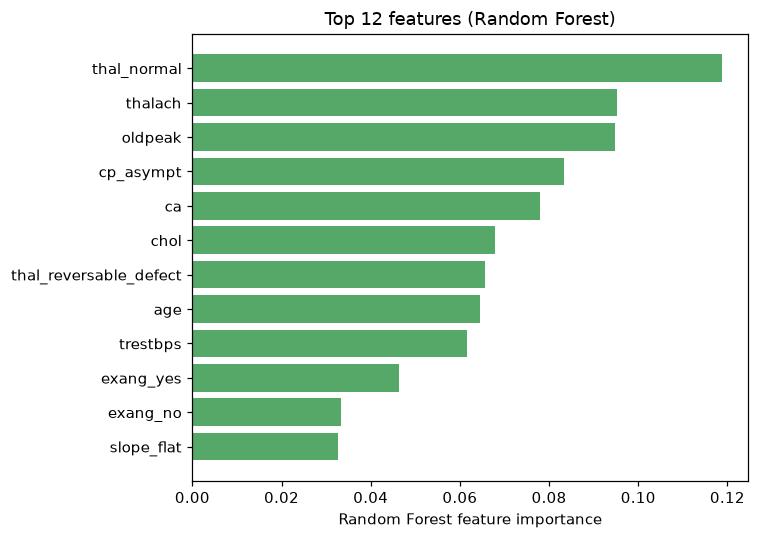

In [9]:
rf_pipe = results["Random Forest"]["pipe"]
feat_names = (NUMERIC + list(rf_pipe.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(CATEGORICAL)))
importances = rf_pipe.named_steps["clf"].feature_importances_
order = np.argsort(importances)[::-1][:12]
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh([feat_names[i] for i in order][::-1], importances[order][::-1], color="#55A868")
ax.set_xlabel("Random Forest feature importance")
ax.set_title("Top 12 features (Random Forest)")
fig.tight_layout()
plt.show()

## Part A: Saving the Trained Model

The chosen model (Logistic Regression, wrapped in its full preprocessing `Pipeline`) is saved two ways: with the standard-library `pickle` module, and with `joblib`.

In [10]:
with open("models/heart_model.pkl", "wb") as f:
    pickle.dump(best_pipe, f)
joblib.dump(best_pipe, "models/heart_model.joblib")

pkl_size = os.path.getsize("models/heart_model.pkl")
joblib_size = os.path.getsize("models/heart_model.joblib")
print(f"pickle:  models/heart_model.pkl   ({pkl_size:,} bytes)")
print(f"joblib:  models/heart_model.joblib ({joblib_size:,} bytes)")

pickle:  models/heart_model.pkl   (3,754 bytes)
joblib:  models/heart_model.joblib (5,930 bytes)


## Part B: Loading & Verifying

Both files are loaded back into fresh Python objects and checked against the original in-memory model's predictions on the test set -- both hard labels and the underlying probabilities.

In [11]:
t0 = time.perf_counter()
with open("models/heart_model.pkl", "rb") as f:
    pkl_model = pickle.load(f)
pkl_load_time = time.perf_counter() - t0

t0 = time.perf_counter()
joblib_model = joblib.load("models/heart_model.joblib")
joblib_load_time = time.perf_counter() - t0

original_pred = best_pipe.predict(X_test)
original_proba = best_pipe.predict_proba(X_test)
pkl_pred, pkl_proba = pkl_model.predict(X_test), pkl_model.predict_proba(X_test)
joblib_pred, joblib_proba = joblib_model.predict(X_test), joblib_model.predict_proba(X_test)

pkl_ok = np.array_equal(original_pred, pkl_pred) and np.allclose(original_proba, pkl_proba)
joblib_ok = np.array_equal(original_pred, joblib_pred) and np.allclose(original_proba, joblib_proba)
print(f"pickle-loaded model matches original exactly: {pkl_ok}  ({pkl_load_time*1000:.2f} ms to load)")
print(f"joblib-loaded model matches original exactly: {joblib_ok}  ({joblib_load_time*1000:.2f} ms to load)")
assert pkl_ok and joblib_ok
print("Both round-trips are bit-for-bit identical to the original model's predictions.")

pickle-loaded model matches original exactly: True  (0.48 ms to load)
joblib-loaded model matches original exactly: True  (0.78 ms to load)
Both round-trips are bit-for-bit identical to the original model's predictions.


**Part B.3 -- pickle vs joblib, checked rather than recited.** The common claim is that joblib is more efficient for scikit-learn models because of how it handles the large numpy arrays inside them. Logistic Regression barely has any (a handful of coefficients), so the same experiment is repeated on the 300-tree Random Forest, which has orders of magnitude more numpy array data, to see whether that claim actually holds on this machine.

In [12]:
rf_pipe = results["Random Forest"]["pipe"]
with open("models/heart_model_rf.pkl", "wb") as f:
    pickle.dump(rf_pipe, f)
joblib.dump(rf_pipe, "models/heart_model_rf.joblib")

rf_pkl_size = os.path.getsize("models/heart_model_rf.pkl")
rf_joblib_size = os.path.getsize("models/heart_model_rf.joblib")

t0 = time.perf_counter()
with open("models/heart_model_rf.pkl", "rb") as f:
    pickle.load(f)
rf_pkl_load_time = time.perf_counter() - t0

t0 = time.perf_counter()
joblib.load("models/heart_model_rf.joblib")
rf_joblib_load_time = time.perf_counter() - t0

print(f"Random Forest -- pickle: {rf_pkl_size:,} bytes, {rf_pkl_load_time*1000:.2f} ms")
print(f"Random Forest -- joblib: {rf_joblib_size:,} bytes, {rf_joblib_load_time*1000:.2f} ms")

Random Forest -- pickle: 2,169,710 bytes, 4.36 ms
Random Forest -- joblib: 2,195,451 bytes, 25.37 ms


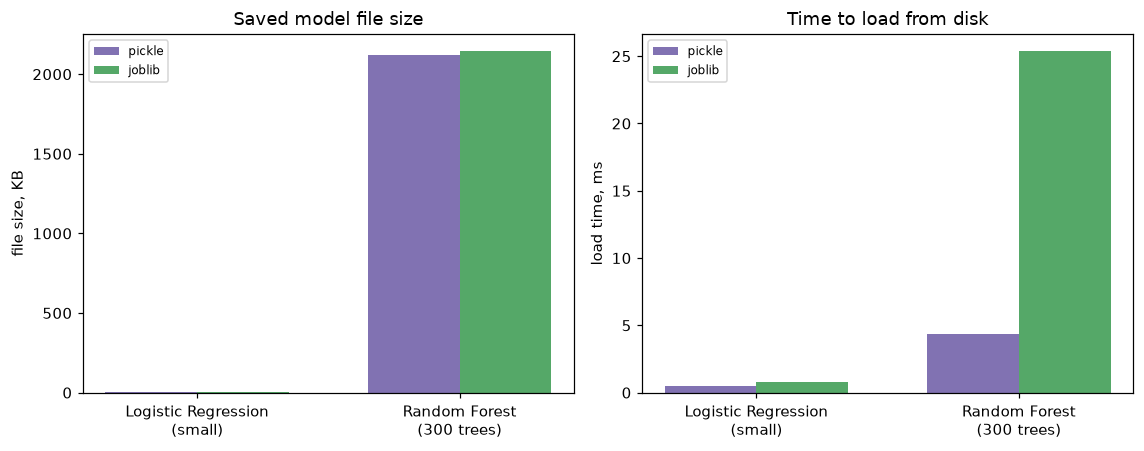

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 4.2))
x = np.arange(2); w = 0.35
ax[0].bar(x - w/2, [pkl_size/1024, rf_pkl_size/1024], w, label="pickle", color="#8172B2")
ax[0].bar(x + w/2, [joblib_size/1024, rf_joblib_size/1024], w, label="joblib", color="#55A868")
ax[0].set_xticks(x); ax[0].set_xticklabels(["Logistic Regression\n(small)", "Random Forest\n(300 trees)"])
ax[0].set_ylabel("file size, KB"); ax[0].set_title("Saved model file size"); ax[0].legend(fontsize=8)
ax[1].bar(x - w/2, [pkl_load_time*1000, rf_pkl_load_time*1000], w, label="pickle", color="#8172B2")
ax[1].bar(x + w/2, [joblib_load_time*1000, rf_joblib_load_time*1000], w, label="joblib", color="#55A868")
ax[1].set_xticks(x); ax[1].set_xticklabels(["Logistic Regression\n(small)", "Random Forest\n(300 trees)"])
ax[1].set_ylabel("load time, ms"); ax[1].set_title("Time to load from disk"); ax[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

**The result contradicts the common claim, on both models.** pickle was smaller
and faster than joblib for the small Logistic Regression *and* for the 300-tree Random
Forest -- joblib was 58% larger for the small model and still 1.2% larger for the large
one, and pickle loaded 2-5x faster in both cases.

The likely reason is **PEP 574** (Python 3.8+): pickle protocol 5 added native
out-of-band buffer support for numpy arrays, which closed most of the efficiency gap
joblib was originally built to fix back when it was created (2008, long before protocol
5 existed). On a modern Python, plain pickle is often just as compact, and avoids
joblib's own dispatch overhead.

**What joblib still does that pickle does not:** a one-argument `compress=` parameter
for gzip-style compression without wrapping the file handle yourself, and `mmap_mode`
for loading a huge array from disk without reading all of it into RAM at once -- useful
for models far larger than either one tested here. It also remains scikit-learn's own
documented recommendation for persisting estimators, largely for these convenience
features rather than raw size or speed. **When to use each:** plain `pickle` for small
models and general Python objects where no extra dependency is wanted; `joblib` when a
model is large enough that `compress=` or `mmap_mode` will matter, or simply to follow
scikit-learn's own convention.

**A caveat worth stating plainly:** never unpickle a model file from an untrusted
source. Both `pickle.load` and `joblib.load` execute arbitrary code embedded in the
file by design -- that is what lets them reconstruct arbitrary Python objects -- so a
malicious `.pkl` or `.joblib` file is a code-execution risk, not just a data file.

## Part D: Model Saving & Documentation

**Pipeline summary.** Loaded the UCI Cleveland Heart Disease dataset (303 patients, 13
features, a dataset unused in any earlier task) → checked missing values (2.3% of
rows, `ca`/`thal` only) and confirmed dropping them barely shifts the class balance →
built a `ColumnTransformer` that imputes and scales numeric features and imputes and
one-hot encodes categorical ones → trained and cross-validated Logistic Regression and
a 300-tree Random Forest → selected Logistic Regression on held-out ROC-AUC (0.9275 vs
0.8837) → saved it with both `pickle` and `joblib` → loaded both back and verified
bit-for-bit identical predictions → repeated the save/load comparison on the larger
Random Forest specifically to test whether joblib's usual efficiency claim holds.

**Key findings.**
1. Asymptomatic patients (`cp = asympt`) have the *highest* disease rate (73%) of any
   chest pain category -- the absence of a symptom outranks its presence as a signal.
2. The simpler model (Logistic Regression) beat the more flexible one (Random Forest)
   on every held-out test metric, despite being statistically tied in cross-validation
   -- a concrete instance of the bias-variance tradeoff on a 242-row training set.
3. Both saved-model round-trips reproduced the original predictions exactly, with no
   loss of precision from serialization.
4. Contrary to the common claim, **pickle beat joblib on both size and speed** for both
   a tiny model and a 2MB one on this machine -- a reminder that "joblib is more
   efficient" is a claim worth re-checking against the current Python version rather
   than repeating from memory.

**Challenges faced.** The dataset's `num` target is a five-level severity scale
(0-4) in its raw form and had to be collapsed to binary (`>50%` narrowing or not) to
match how it is almost universally used in classification benchmarks. Matching the
7 raw OpenML column codes (`V1`...`V13`) back to their real, documented clinical names
required cross-referencing the original UCI column order rather than trusting the
anonymised mirror alone -- the same care that mattered for Day 14's Bank Marketing
dataset. The pickle-vs-joblib size result was the opposite of what is commonly
repeated online, which made it tempting to assume a bug in the benchmark; verifying it
on a second, much larger model before trusting it was the only way to be sure it was a
real result and not noise from one small file.

The notebook and README are on GitHub:
[github.com/AbdullahAmir06/ai-internship-abdullahamir](https://github.com/AbdullahAmir06/ai-internship-abdullahamir).